# Basis
This is the last abstraction layer considering that the CGTO layer has been defined and that it works. In the previous notebook, we required to explicitly calculate the integral matrix for each pair of CGTOs. The idea is now that by passing a list of CGTOs, the complete integral matrices are calculated automatically. 

In [1]:
from py_mods.src.integrals.CGTO import (
    create_CGTOClass,
    S_GTO_mat,
    generate_angular_momentum_projections,
    T_GTO_mat,
    V_GTO_mat,
    Eri_GTO_tensor,
    CGTOClass,
)
from py_mods.src.SCF.plot_utilities import plot_map
from dataclasses import dataclass
from typing import List
from numpy.typing import NDArray
import numpy as np

from pyscf import gto

In [2]:
@dataclass
class BasisSet:
    CGTOs: List[CGTOClass]
    n_CGTOs: int
    matrix_indices: NDArray[np.int16]
    l_dims: NDArray[np.int16]
    r_atoms: NDArray[np.float64]
    q_atoms: NDArray[np.float64]

For the sake of the argument, instead of starting with the constructor, we will start with the previous example of He and manually building the basis set.

In [3]:
l = 0
l_tags = ["S", "P", "D", "F", "G", "H"]
l_projs = len(generate_angular_momentum_projections(l))

r1 = np.array([0.0, 0.0, 0.0])
r2 = np.array([0.0, 0.0, 1.4])

H_exps = np.array([3.42525091, 0.62391373, 0.16885540])
H_coeffs = np.array([0.15432897, 0.53532814, 0.44463454])

atom_pos = np.array([[0.0, 0.0, 0.0], [0.0, 0.0, 1.4]])
atom_charges = np.array([1.0, 1.0])

# Construct the CGTO
H_1s_1 = create_CGTOClass(r1, H_exps, H_coeffs, l)
H_1p_1 = create_CGTOClass(r1, H_exps, H_coeffs, l + 1)
H_1d_1 = create_CGTOClass(r1, H_exps, H_coeffs, l + 2)
H_1s_2 = create_CGTOClass(r2, H_exps, H_coeffs, l)
H_1p_2 = create_CGTOClass(r2, H_exps, H_coeffs, l + 1)
H_1d_2 = create_CGTOClass(r2, H_exps, H_coeffs, l + 2)

In [4]:
def construct_basis_from_lists(cgto_list, r_atom_list, q_atom_list) -> BasisSet:
    if len(r_atom_list) != len(q_atom_list):
        raise ValueError("Length of r_atom_list and q_atom_list must be the same.")

    projections = [basis.l_dim for basis in cgto_list]
    cgto_indices = [sum(projections[:i]) for i in range(len(cgto_list))]
    cgto_indices.append(projections[-1] + cgto_indices[-1])

    basis_set = BasisSet(
        CGTOs=cgto_list,
        n_CGTOs=len(cgto_list),
        matrix_indices=cgto_indices,
        l_dims=np.array(projections, dtype=np.int16),
        r_atoms=np.array(r_atom_list, dtype=np.float64),
        q_atoms=np.array(q_atom_list, dtype=np.float64),
    )

    return basis_set

In [5]:
bs = construct_basis_from_lists(
    [H_1s_1, H_1p_1, H_1d_1, H_1s_2, H_1p_2, H_1d_2], atom_pos, atom_charges
)

In [6]:
for attribute in bs.__dataclass_fields__:
    if attribute != "CGTOs":
        print(f"{attribute}: {getattr(bs, attribute)}")

n_CGTOs: 6
matrix_indices: [0, 1, 4, 10, 11, 14, 20]
l_dims: [1 3 6 1 3 6]
r_atoms: [[0.  0.  0. ]
 [0.  0.  1.4]]
q_atoms: [1. 1.]


In [7]:
def S_basis_set(basis_set: BasisSet) -> NDArray[np.float64]:
    n_CGTOs = basis_set.n_CGTOs
    S_mat = np.zeros((basis_set.matrix_indices[-1], basis_set.matrix_indices[-1]))

    for i in range(n_CGTOs):
        for j in range(n_CGTOs):

            index_i = basis_set.matrix_indices[i]
            index_i_stop = basis_set.matrix_indices[i + 1]
            index_j = basis_set.matrix_indices[j]
            index_j_stop = basis_set.matrix_indices[j + 1]

            S_mat[index_i:index_i_stop, index_j:index_j_stop] = S_GTO_mat(
                basis_set.CGTOs[i], basis_set.CGTOs[j]
            )

    return S_mat

def V_basis_set(basis_set: BasisSet) -> NDArray[np.float64]:
    n_CGTOs = basis_set.n_CGTOs
    S_mat = np.zeros((basis_set.matrix_indices[-1], basis_set.matrix_indices[-1]))

    for i in range(n_CGTOs):
        for j in range(n_CGTOs):

            index_i = basis_set.matrix_indices[i]
            index_i_stop = basis_set.matrix_indices[i + 1]
            index_j = basis_set.matrix_indices[j]
            index_j_stop = basis_set.matrix_indices[j + 1]

            S_mat[index_i:index_i_stop, index_j:index_j_stop] = V_GTO_mat(
                basis_set.CGTOs[i], basis_set.CGTOs[j], basis_set.r_atoms, basis_set.q_atoms
            )

    return S_mat

def T_basis_set(basis_set: BasisSet) -> NDArray[np.float64]:
    n_CGTOs = basis_set.n_CGTOs
    S_mat = np.zeros((basis_set.matrix_indices[-1], basis_set.matrix_indices[-1]))

    for i in range(n_CGTOs):
        for j in range(n_CGTOs):

            index_i = basis_set.matrix_indices[i]
            index_i_stop = basis_set.matrix_indices[i + 1]
            index_j = basis_set.matrix_indices[j]
            index_j_stop = basis_set.matrix_indices[j + 1]

            S_mat[index_i:index_i_stop, index_j:index_j_stop] = T_GTO_mat(
                basis_set.CGTOs[i], basis_set.CGTOs[j]
            )

    return S_mat

def eri_basis_set(basis_set: BasisSet) -> NDArray[np.float64]:
    n_CGTOs = basis_set.n_CGTOs
    dim = basis_set.matrix_indices[-1]
    eri_tensor = np.zeros((dim, dim, dim, dim))

    for i in range(n_CGTOs):
        for j in range(n_CGTOs):
            for k in range(n_CGTOs):
                for l in range(n_CGTOs):

                    index_i = basis_set.matrix_indices[i]
                    index_i_stop = basis_set.matrix_indices[i + 1]
                    index_j = basis_set.matrix_indices[j]
                    index_j_stop = basis_set.matrix_indices[j + 1]
                    index_k = basis_set.matrix_indices[k]
                    index_k_stop = basis_set.matrix_indices[k + 1]
                    index_l = basis_set.matrix_indices[l]
                    index_l_stop = basis_set.matrix_indices[l + 1]

                    eri_tensor[
                        index_i:index_i_stop,
                        index_j:index_j_stop,
                        index_k:index_k_stop,
                        index_l:index_l_stop,
                    ] = Eri_GTO_tensor(
                        basis_set.CGTOs[i],
                        basis_set.CGTOs[j],
                        basis_set.CGTOs[k],
                        basis_set.CGTOs[l],
                    )

    return eri_tensor

In [8]:
S_bs = S_basis_set(bs)
T_bs = T_basis_set(bs)
V_bs = V_basis_set(bs)

In [9]:
from pyscf import gto

mol = gto.M(
    atom="H 0 0 0; H 0 0 1.4;",
    unit="Bohr",
    basis={
        "H": gto.basis.parse(
            f"""
        # This is the standard STO-3G definition
        # Exponent    Contraction Coeff
        H S
        3.42525091    0.15432897
        0.62391373    0.53532814
        0.16885540    0.44463454
        H P
        3.42525091    0.15432897
        0.62391373    0.53532814
        0.16885540    0.44463454
        H D
        3.42525091    0.15432897
        0.62391373    0.53532814
        0.16885540    0.44463454
    """
        )
    },
    cart=True,
    spin=0,
)

mol.build()

overlap = mol.intor("int1e_ovlp")
kin = mol.intor("int1e_kin")
V = mol.intor("int1e_nuc")
ref_eri = mol.intor("int2e")

# pyscf does not normalize in cartesian like this, we have to renormalize to compare
norm_vec = 1.0 / np.sqrt(np.diag(overlap))

overlap *= norm_vec[:, None]
overlap *= norm_vec[None, :]

kin *= norm_vec[:, None]
kin *= norm_vec[None, :]

V *= norm_vec[:, None]
V *= norm_vec[None, :]

ref_eri *= norm_vec[:, None, None, None]
ref_eri *= norm_vec[None, :, None, None]
ref_eri *= norm_vec[None, None, :, None]
ref_eri *= norm_vec[None, None, None, :]

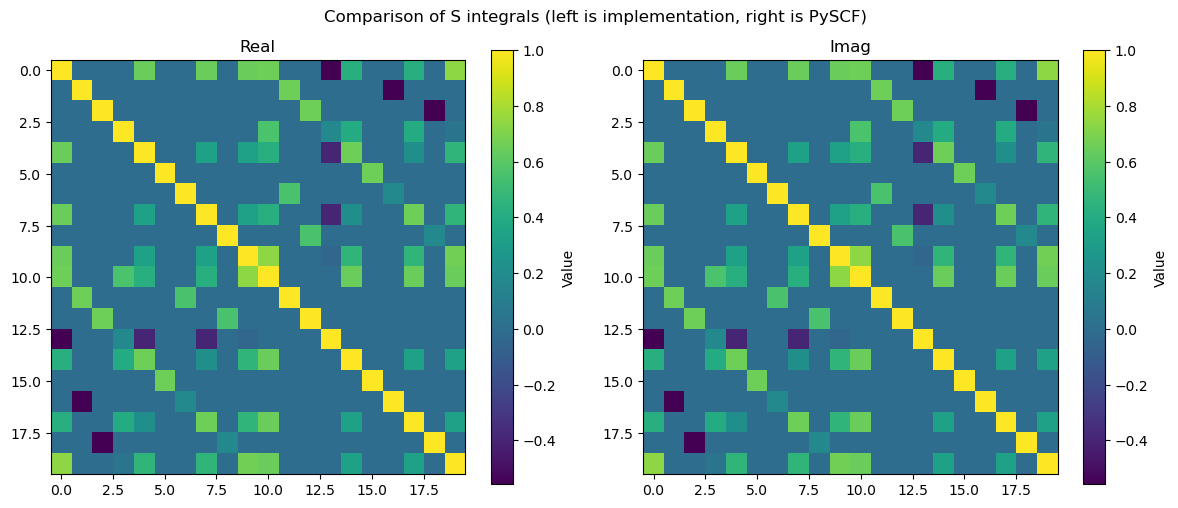

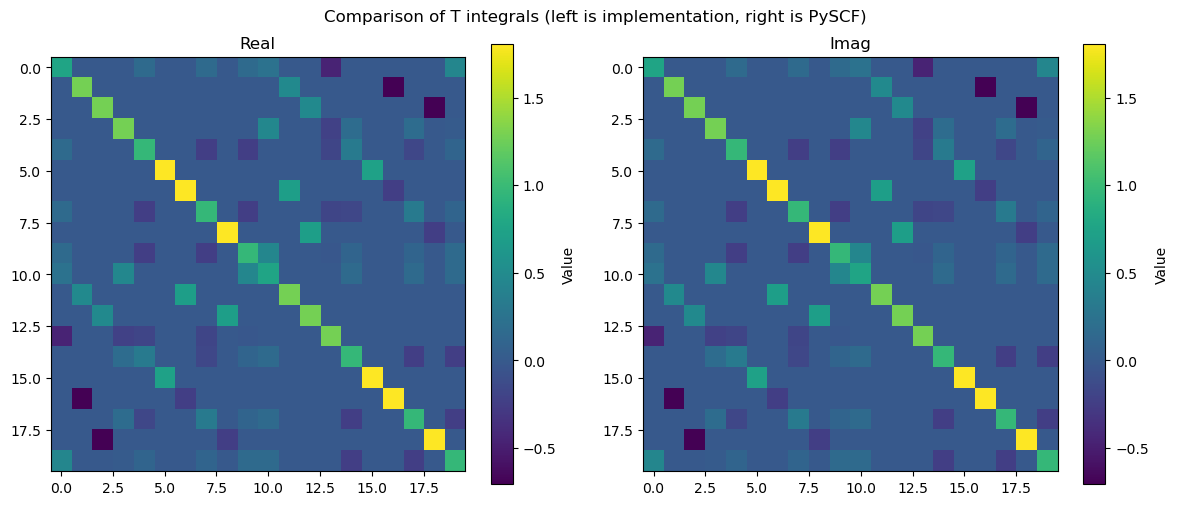

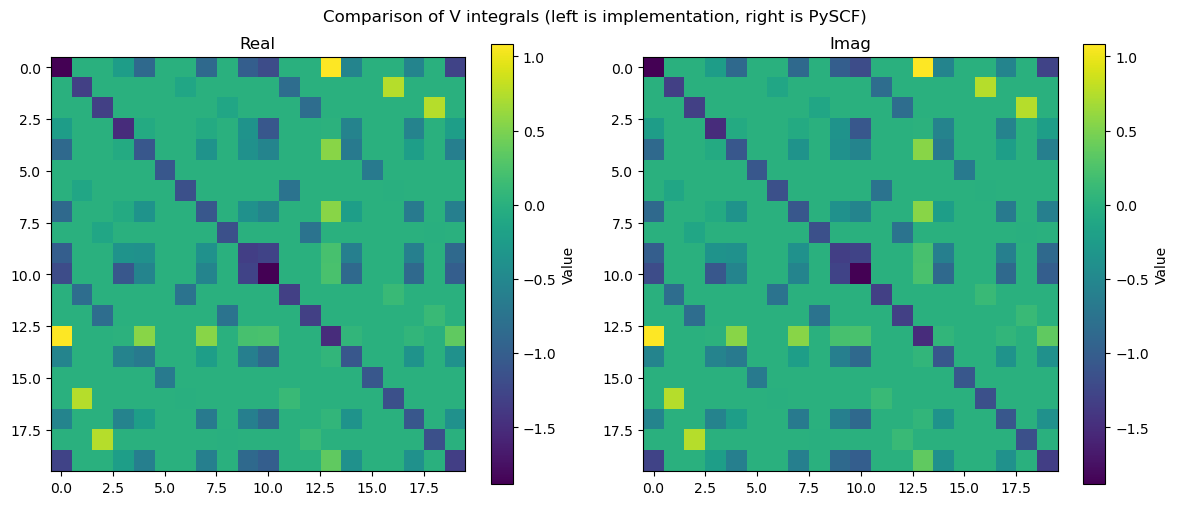

In [10]:
plot_map(S_bs+overlap*1j, title="Comparison of S integrals (left is implementation, right is PySCF)")
plot_map(T_bs+kin*1j, title="Comparison of T integrals (left is implementation, right is PySCF)")
plot_map(V_bs+V*1j, title="Comparison of V integrals (left is implementation, right is PySCF)")


In [11]:
print(np.allclose(S_bs, overlap))
print(np.allclose(T_bs, kin))
print(np.allclose(V_bs, V))

True
True
True


---

In [ ]:
# this takes around 1:45
bs = construct_basis_from_lists(
    [H_1s_1, H_1p_1, H_1s_2, H_1p_2], atom_pos, atom_charges
)

S_bs = S_basis_set(bs)
T_bs = T_basis_set(bs)
V_bs = V_basis_set(bs)
eri_bs = eri_basis_set(bs)


In [13]:
from pyscf import gto

mol = gto.M(
    atom="H 0 0 0; H 0 0 1.4;",
    unit="Bohr",
    basis={
        "H": gto.basis.parse(
            f"""
        # This is the standard STO-3G definition
        # Exponent    Contraction Coeff
        H S
        3.42525091    0.15432897
        0.62391373    0.53532814
        0.16885540    0.44463454
        H P
        3.42525091    0.15432897
        0.62391373    0.53532814
        0.16885540    0.44463454
    """
        )
    },
    cart=True,
    spin=0,
)

mol.build()


overlap = mol.intor("int1e_ovlp")
kin = mol.intor("int1e_kin")
V = mol.intor("int1e_nuc")
ref_eri = mol.intor("int2e")

# pyscf does not normalize in cartesian like this, we have to renormalize to compare
norm_vec = 1.0 / np.sqrt(np.diag(overlap))

overlap *= norm_vec[:, None]
overlap *= norm_vec[None, :]

kin *= norm_vec[:, None]
kin *= norm_vec[None, :]

V *= norm_vec[:, None]
V *= norm_vec[None, :]

ref_eri *= norm_vec[:, None, None, None]
ref_eri *= norm_vec[None, :, None, None]
ref_eri *= norm_vec[None, None, :, None]
ref_eri *= norm_vec[None, None, None, :]

In [14]:
print(np.allclose(S_bs, overlap))
print(np.allclose(T_bs, kin))
print(np.allclose(V_bs, V))
print(np.allclose(eri_bs, ref_eri))

True
True
True
True
